In [63]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


In [74]:
df_fhs = (
    pl.read_parquet("../data/fhs_results/*.parquet")
    .with_columns(model=pl.lit("fhs_ewma_500"))
    .select("symbol", "fit_key", "model", "d_t", "r_t->t+1", "var_t->t+1")
)

df_caviar = (
    pl.read_parquet("../data/caviar_results/*.parquet")
    .with_columns(model=pl.lit("caviar") + "_" + pl.col("approach"))
    .drop("approach")
    .group_by("symbol", "fit_key", "model")
    .map_groups(
        lambda df: (
            df.sort("d_t").with_columns(pl.col("r_t-1->t").shift(-1).alias("r_t->t+1"))
        )
    )
    .select(df_fhs.columns)
)

df_all = pl.concat([df_fhs, df_caviar])

df_all

symbol,fit_key,model,d_t,r_t->t+1,var_t->t+1
str,str,str,date,f64,f64
"""BND""","""1f9c23e7-f05d-44f9-ae21-e71acc…","""fhs_ewma_500""",2022-01-04,-0.003445,null
"""BND""","""1f9c23e7-f05d-44f9-ae21-e71acc…","""fhs_ewma_500""",2022-01-05,-0.001072,null
"""BND""","""1f9c23e7-f05d-44f9-ae21-e71acc…","""fhs_ewma_500""",2022-01-06,-0.002745,null
"""BND""","""1f9c23e7-f05d-44f9-ae21-e71acc…","""fhs_ewma_500""",2022-01-07,-0.000838,null
"""BND""","""1f9c23e7-f05d-44f9-ae21-e71acc…","""fhs_ewma_500""",2022-01-10,0.002037,null
…,…,…,…,…,…
"""VDE""","""69f8dfcf-673f-40fa-b1e6-9f42ba…","""caviar_IG""",2026-06-24,0.011002,-0.038162
"""VDE""","""69f8dfcf-673f-40fa-b1e6-9f42ba…","""caviar_IG""",2026-06-25,-0.003081,-0.039378
"""VDE""","""69f8dfcf-673f-40fa-b1e6-9f42ba…","""caviar_IG""",2026-06-26,-0.005195,-0.037995


In [75]:
import datetime
from typing import cast

NAME_MAP = {
    "SPY": "State Street SPDR S&P 500 ETF",
    "VDE": "Vanguard Energy ETF",
    "BND": "Vanguard Total Bond Market ETF",
    "FEZ": "State Street SPDR EURO STOXX 50 ETF",
}


symbols = df_all["symbol"].unique()
models = df_all["model"].unique().sort().to_list()

for symbol in symbols:
    with plt.style.context("minimalist.mplstyle"):
        fig, ax = plt.subplots()
        fig.set_size_inches((14, 4))

        df_ = df_all.filter(pl.col("symbol").eq(symbol))

        df_rets = df_.select("d_t", "r_t->t+1").unique()

        ax.set_title(f"{NAME_MAP[symbol]} ({symbol})")
        ax.scatter(
            df_rets["d_t"],
            df_rets["r_t->t+1"],
            marker="x",
            color="gray",
            alpha=0.3,
            s=10,
        )

        first_date = df_.filter(pl.col("var_t->t+1").is_not_null())["d_t"].min()

        for model in models:
            df_model = (
                df_.filter(pl.col("model").eq(model))
                .filter(pl.col("var_t->t+1").is_not_null())
                .filter(pl.col("d_t").dt.year().ge(2024))
            )
            ax.plot(
                df_model["d_t"],
                df_model["var_t->t+1"],
                label=model,
                linewidth=1,
                alpha=0.8,
            )

            ax.legend()

        ax.set_xlim(left=cast(datetime.date, first_date) - datetime.timedelta(days=10))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

        fig.savefig(f"vars_{symbol}.png")


In [76]:
models = df_all["model"].unique().sort().to_list()

for symbol in symbols:
    with plt.style.context("minimalist.mplstyle"):
        fig, ax = plt.subplots()
        fig.set_size_inches((14, 4))

        df_ = df_all.filter(pl.col("symbol").eq(symbol))

        ax.set_title(f"{NAME_MAP[symbol]} ({symbol})")
        first_date = df_.filter(pl.col("var_t->t+1").is_not_null())["d_t"].min()

        for model in models:
            df_model = (
                df_.filter(pl.col("model").eq(model))
                .sort("d_t")
                .filter(pl.col("var_t->t+1").is_not_null())
                .with_row_index()
                .with_columns(
                    var_roll=pl.col("var_t->t+1").rolling("index", period="20i")
                )
                .filter(pl.col("var_roll").list.len() == 20)
                .with_columns(
                    pl.col("var_roll").list.std().alias("var_std"),
                    pl.col("var_roll").list.mean().abs().alias("var_mean"),
                )
                .with_columns(
                    pl.col("var_std").truediv(pl.col("var_mean")).alias("var_cv")
                )
            )

            ax.plot(
                df_model["d_t"],
                df_model["var_cv"],
                label=model,
                linewidth=1,
                alpha=0.8,
            )

            ax.legend()

        ax.set_xlim(left=cast(datetime.date, first_date) - datetime.timedelta(days=10))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

        fig.savefig(f"var_cvs_{symbol}.png")


In [77]:
df_all.filter(pl.col("var_t->t+1").is_not_null()).group_by("model").agg(
    pl.col("d_t").min()
)

model,d_t
str,date
"""caviar_SAV""",2024-01-02
"""caviar_IG""",2024-01-02
"""fhs_ewma_500""",2023-12-29
"""caviar_AS""",2024-01-02


In [78]:
df_all.filter(pl.col("symbol") == "FEZ")["model"].unique()

model
str
"""caviar_SAV"""
"""caviar_AS"""
"""fhs_ewma_500"""
"""caviar_IG"""


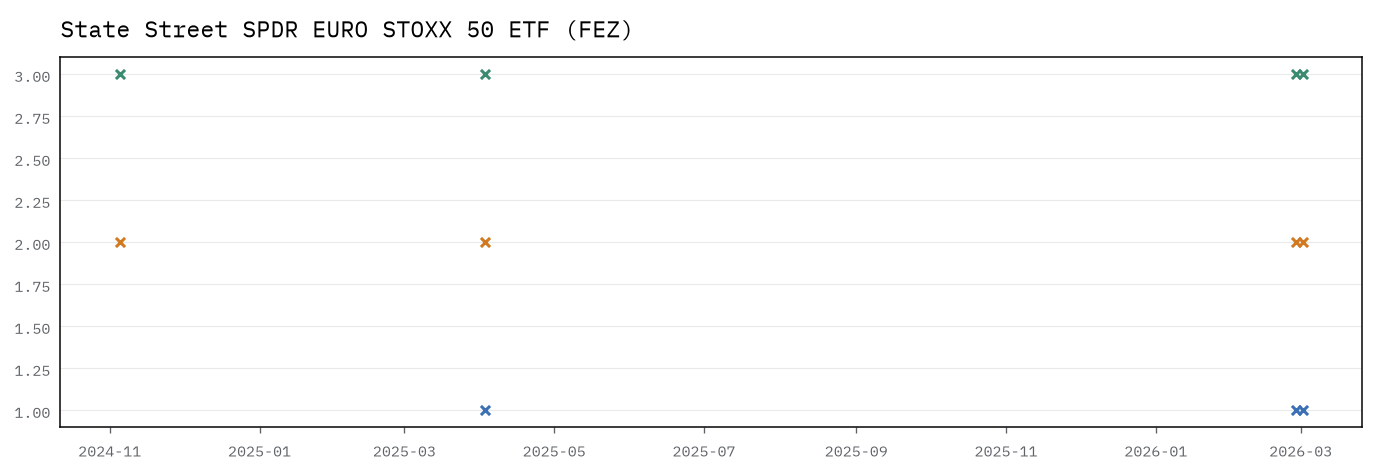

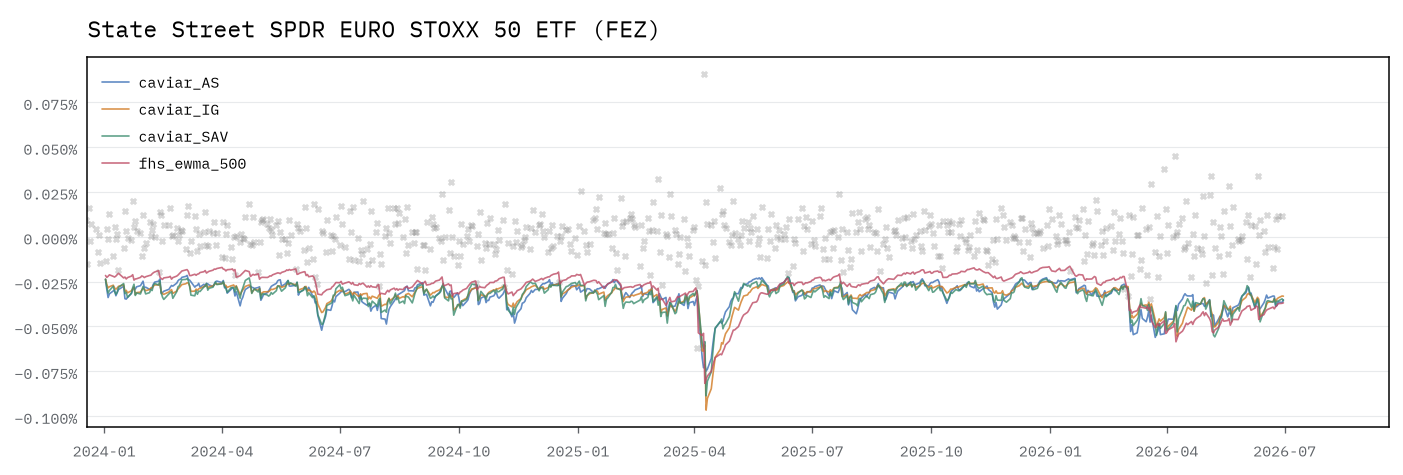

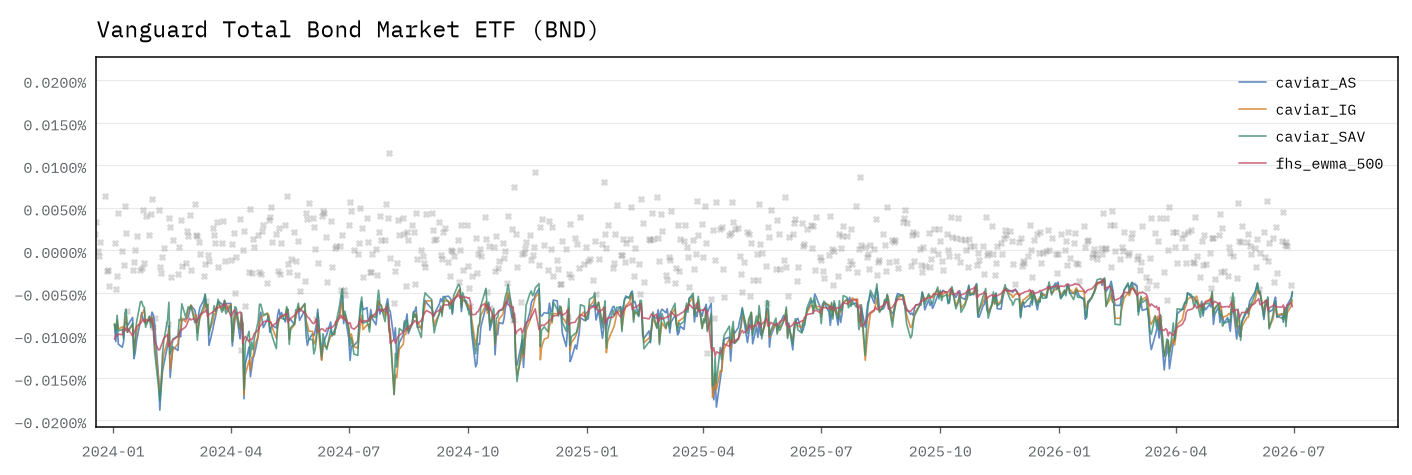

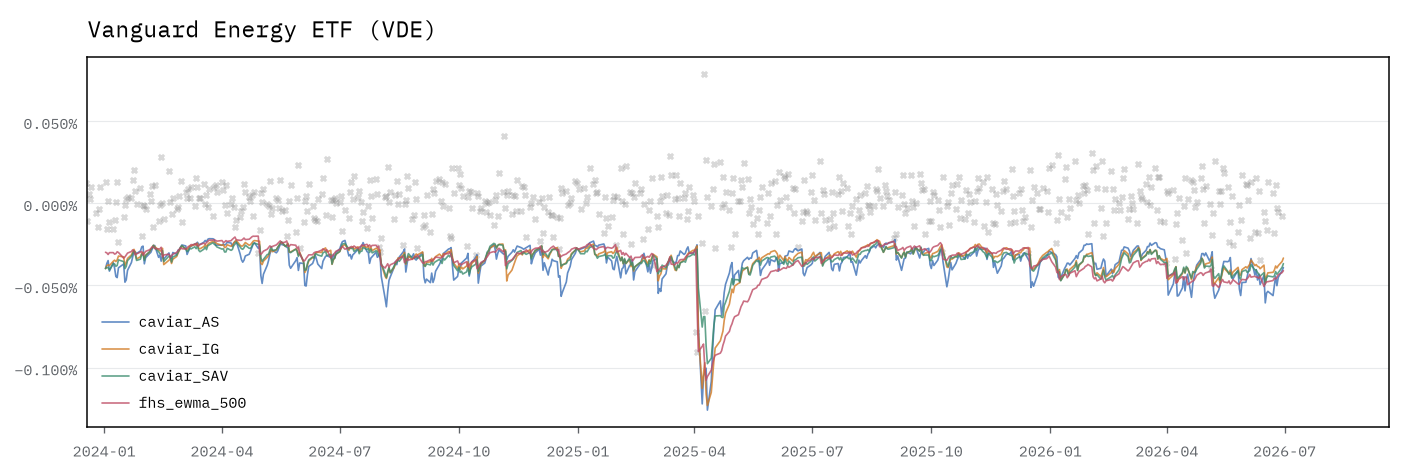

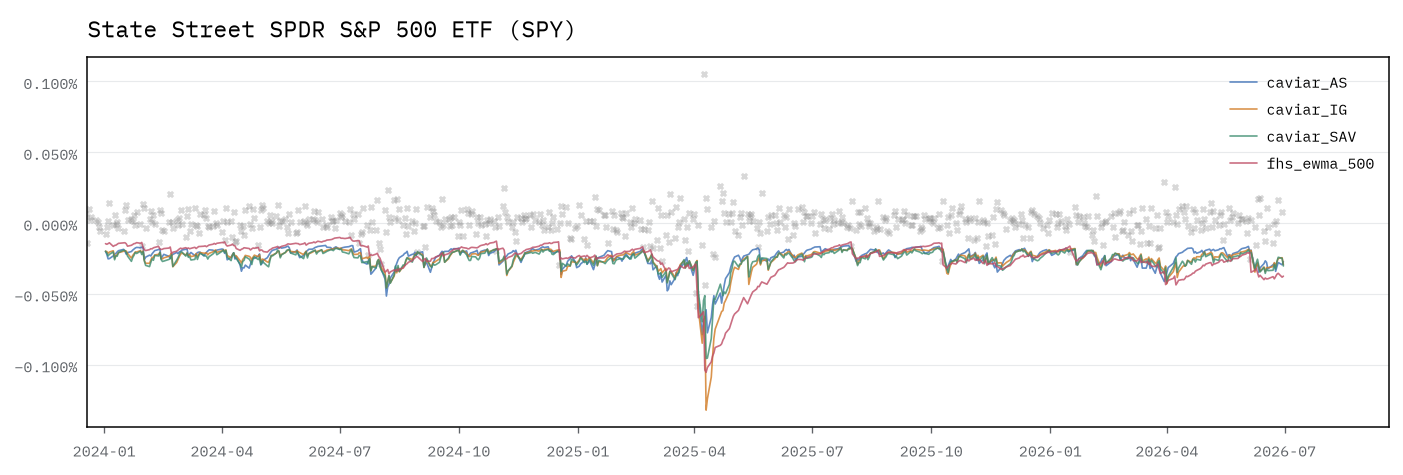

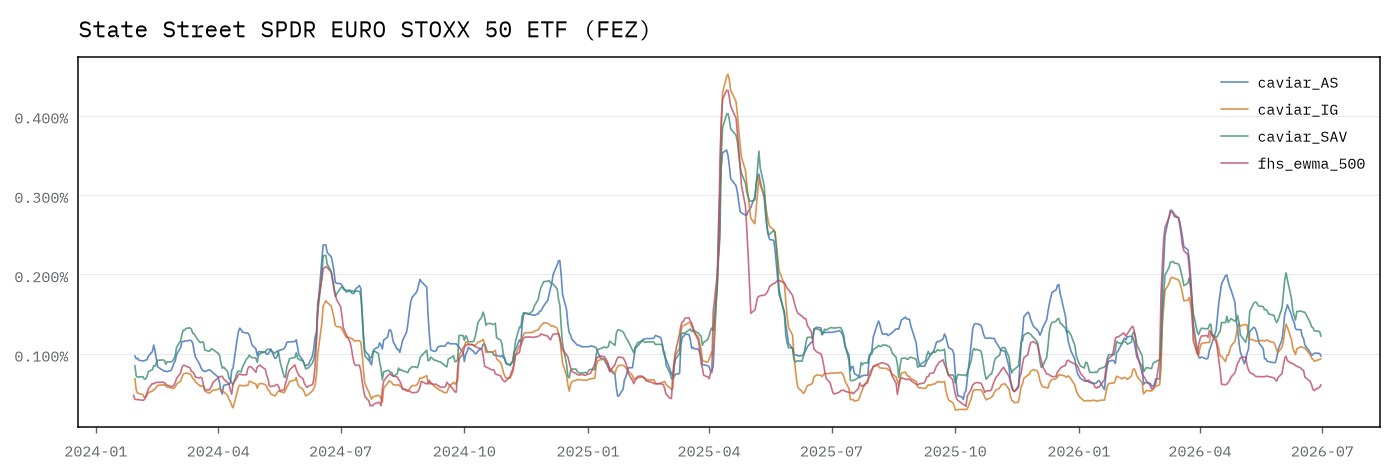

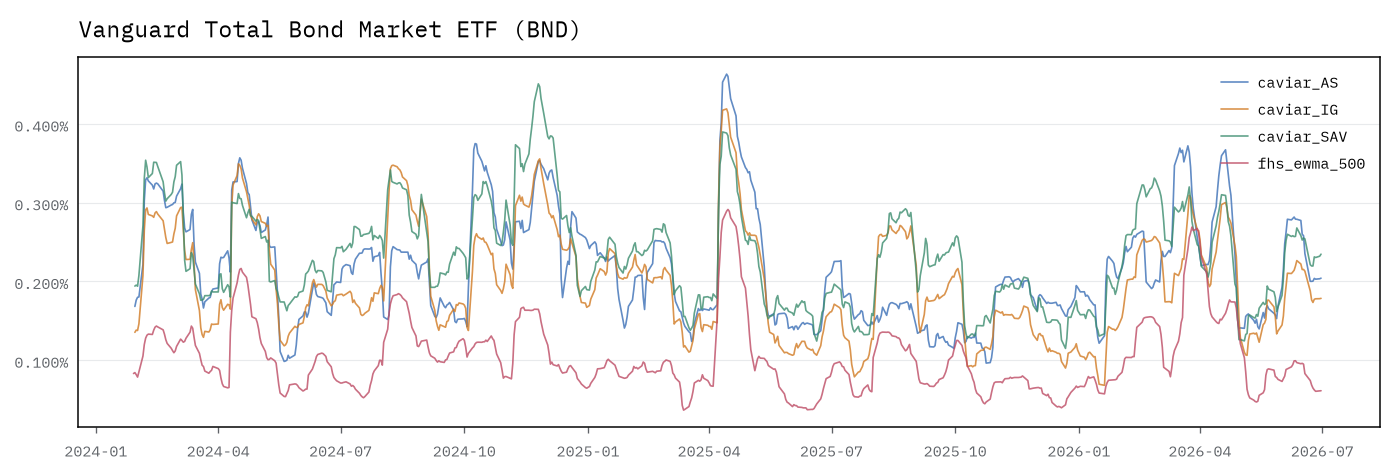

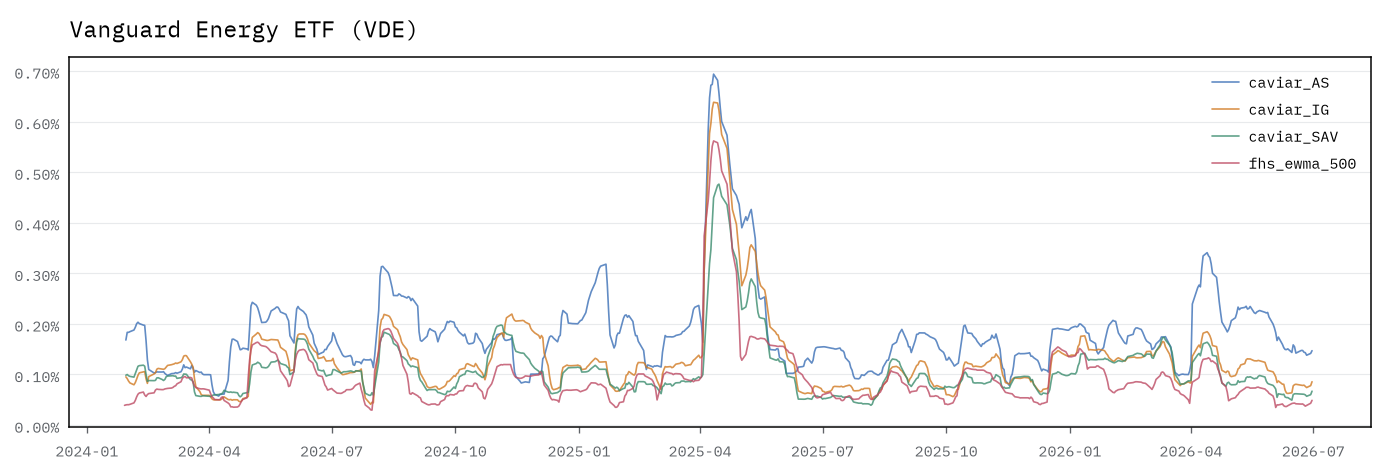

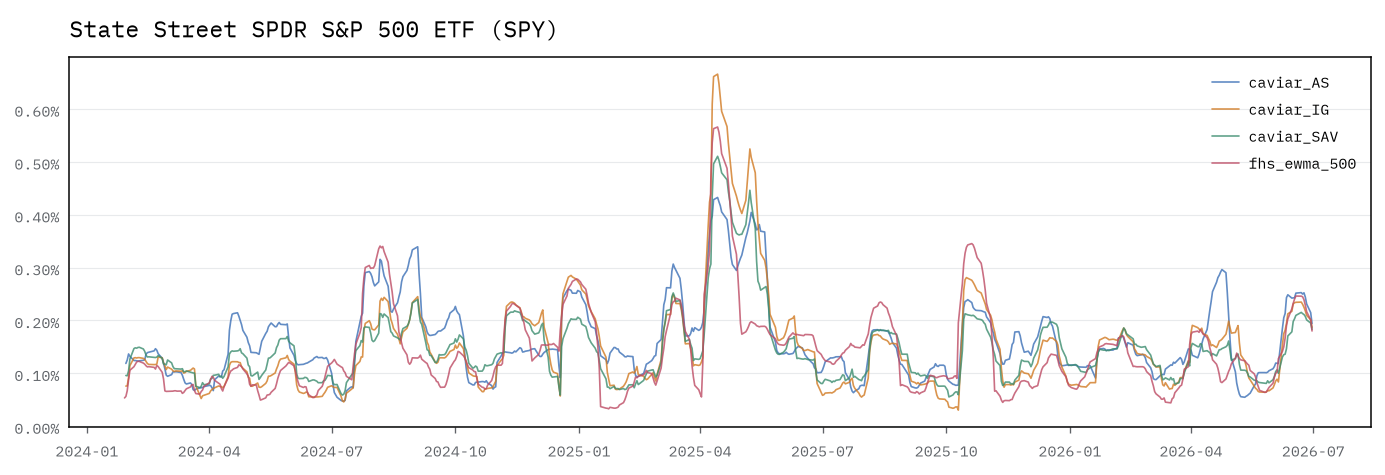

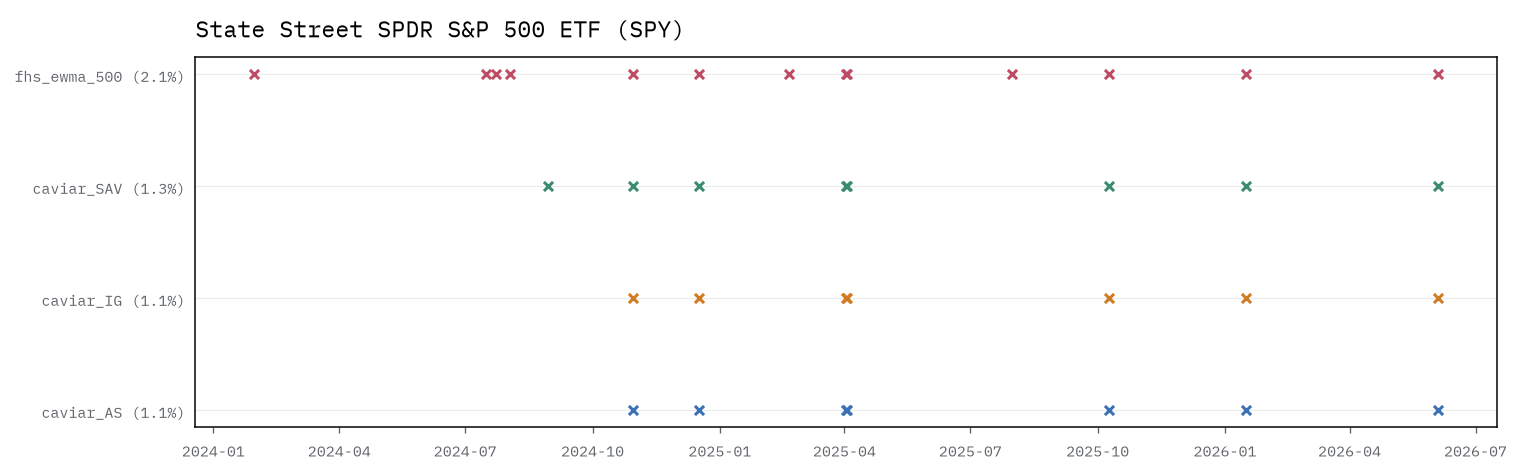

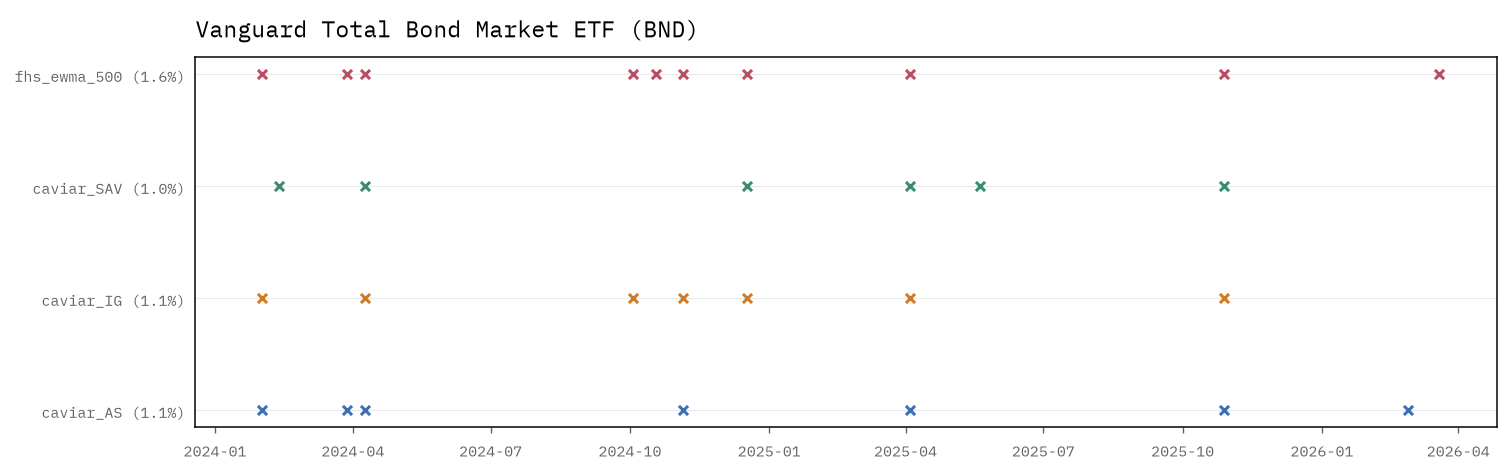

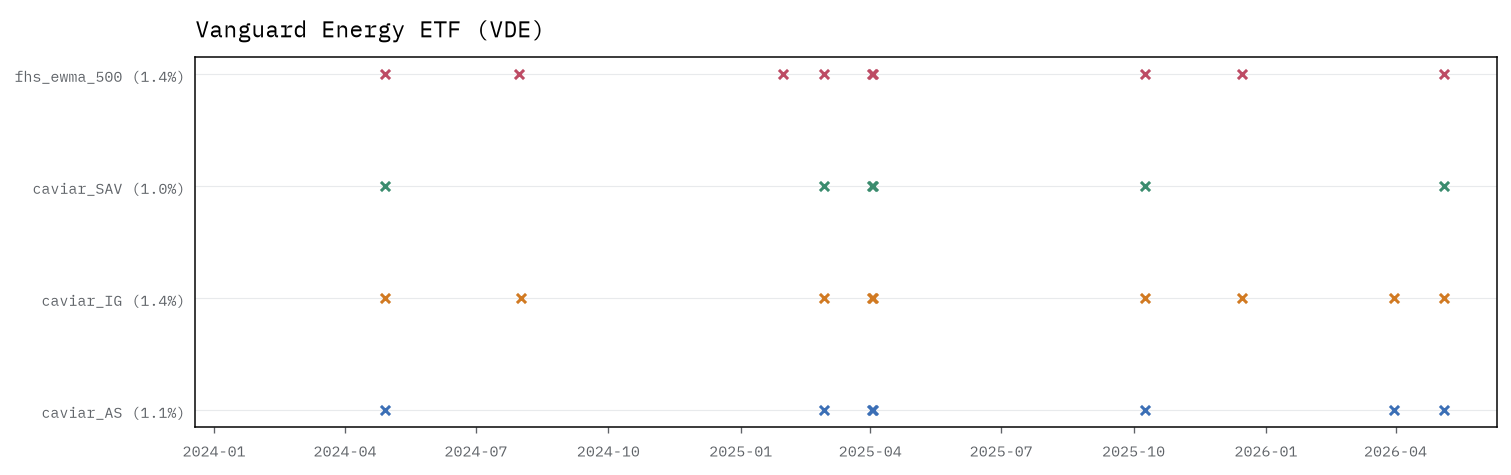

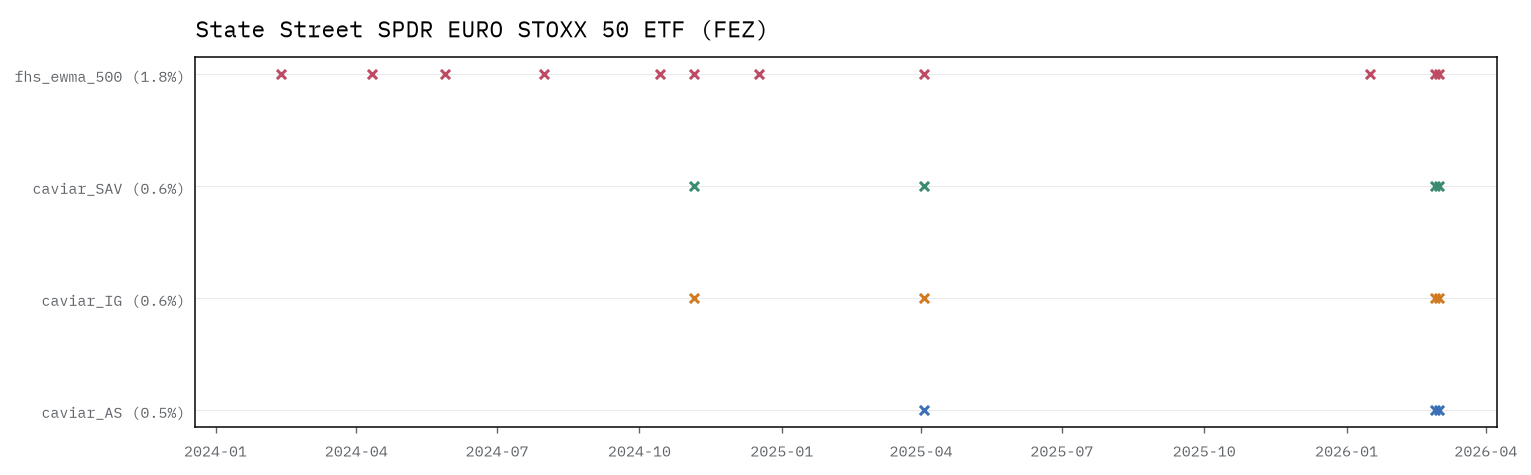

In [79]:
import datetime
from typing import cast


symbols = df_all["symbol"].unique()
models = df_all["model"].unique().sort().to_list()

model_map = {k: i + 1 for i, k in enumerate(models)}
os_freq = {}

for symbol in symbols:
    with plt.style.context("minimalist.mplstyle"):
        fig, ax = plt.subplots()
        fig.set_size_inches((14, 4))

        df_ = df_all.filter(pl.col("symbol").eq(symbol))

        ax.set_title(f"{NAME_MAP[symbol]} ({symbol})")
        first_date = df_.filter(pl.col("var_t->t+1").is_not_null())["d_t"].min()

        for model in models:
            df_model = (
                df_.filter(pl.col("model").eq(model))
                .filter(pl.col("var_t->t+1").is_not_null())
                .filter(pl.col("d_t").dt.year().ge(2024))
            )
            df_os = df_model.filter(
                pl.col("r_t->t+1").lt(pl.col("var_t->t+1"))
            ).with_columns(idx=model_map[model])

            os_freq[model] = df_os.height / df_model.height

            ax.scatter(df_os["d_t"], df_os["idx"], label=model, marker="x", s=30)

        ax.set_xlim(left=cast(datetime.date, first_date) - datetime.timedelta(days=10))
        ax.set_yticks(list(model_map.values()))
        ax.set_yticklabels([f"{model} ({os_freq[model]:.1%})" for model in models])

        fig.savefig(f"os_{symbol}.png")

        plt.show()


In [80]:
from scipy import stats


with pl.Config(tbl_formatting="MARKDOWN", tbl_rows=100000):
    df_all.filter(pl.col("var_t->t+1").is_not_null()).filter(
        pl.col("r_t->t+1").is_not_null()
    ).with_columns(os=pl.col("r_t->t+1").lt(pl.col("var_t->t+1"))).group_by(
        "symbol", "model"
    ).agg(
        m=pl.col("os").sum(),
        n=pl.col("os").len(),
        f=pl.col("os").sum() / pl.col("os").len(),
    ).with_columns(th_f=pl.lit(0.01), th_m=pl.lit(0.01).mul(pl.col("n"))).with_columns(
        kupiec_num=pl.col("th_f")
        .pow(pl.col("m"))
        .mul(pl.lit(1).sub(pl.col("th_f")).pow(pl.col("n").sub(pl.col("m")))),
        kupiec_denom=pl.col("f")
        .pow(pl.col("m"))
        .mul(pl.lit(1).sub(pl.col("f")).pow(pl.col("n").sub(pl.col("m")))),
    ).with_columns(
        kupiec_lr=-pl.lit(2).mul(
            pl.col("kupiec_num").truediv(pl.col("kupiec_denom")).log()
        )
    ).with_columns(
        kupiec_pval=pl.col("kupiec_lr").map_elements(
            lambda lr: 1 - stats.chi2.cdf(lr, df=1), return_dtype=pl.Float64
        ),
        kupiec_rej=pl.col("kupiec_lr").gt(stats.chi2.ppf(q=0.95, df=1)),
    ).select("symbol", "model", "kupiec_pval", "kupiec_rej").sort(
        "symbol", "model"
    ).pipe(print)

shape: (16, 4)
| symbol | model        | kupiec_pval | kupiec_rej |
| ---    | ---          | ---         | ---        |
| str    | str          | f64         | bool       |
|--------|--------------|-------------|------------|
| BND    | caviar_AS    | 0.764234    | false      |
| BND    | caviar_IG    | 0.764234    | false      |
| BND    | caviar_SAV   | 0.922581    | false      |
| BND    | fhs_ewma_500 | 0.165543    | false      |
| FEZ    | caviar_AS    | 0.147034    | false      |
| FEZ    | caviar_IG    | 0.3347      | false      |
| FEZ    | caviar_SAV   | 0.3347      | false      |
| FEZ    | fhs_ewma_500 | 0.084641    | false      |
| SPY    | caviar_AS    | 0.764234    | false      |
| SPY    | caviar_IG    | 0.764234    | false      |
| SPY    | caviar_SAV   | 0.497437    | false      |
| SPY    | fhs_ewma_500 | 0.017803    | true       |
| VDE    | caviar_AS    | 0.764234    | false      |
| VDE    | caviar_IG    | 0.297638    | false      |
| VDE    | caviar_SAV   | 0.922

np.float64(3.8414588206941205)